In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:

# Load dataset
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [3]:
train_loader = DataLoader(train_dataset, batch_size=500, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=500)

In [4]:
# 1. Neural Network Mini

class DigitClassifierMini(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(28*28, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        return self.network(x)        


# 2. Neural Network
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

# 3. Convolutional Neural Network
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 28x28 -> 14x14
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

model1 = DigitClassifierMini()
model2 = DigitClassifier()
model3 = DigitCNN()

criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)
optimizer3 = optim.Adam(model3.parameters(), lr=0.001)

In [5]:
# Training
def train(model, optimizer, epochs=10):
    losses = []
    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            outputs = model(images)

            loss = criterion(outputs, labels)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    return losses

print("Training DigitClassifierMini (32-32)...")
losses1 = train(model1, optimizer1)

print("\nTraining DigitClassifierMini (128-64)...")
losses2 = train(model2, optimizer2)

print("\nTraining DigitCNN...")
losses3 = train(model3, optimizer3)

Training DigitClassifierMini (32-32)...
Epoch 1, Loss: 0.4702
Epoch 2, Loss: 0.4235
Epoch 3, Loss: 0.2565
Epoch 4, Loss: 0.2611
Epoch 5, Loss: 0.2229
Epoch 6, Loss: 0.1563
Epoch 7, Loss: 0.2016
Epoch 8, Loss: 0.1210
Epoch 9, Loss: 0.1754
Epoch 10, Loss: 0.1624

Training DigitClassifierMini (128-64)...
Epoch 1, Loss: 0.3385
Epoch 2, Loss: 0.2249
Epoch 3, Loss: 0.2075
Epoch 4, Loss: 0.1491
Epoch 5, Loss: 0.1249
Epoch 6, Loss: 0.1242
Epoch 7, Loss: 0.0956
Epoch 8, Loss: 0.1250
Epoch 9, Loss: 0.0815
Epoch 10, Loss: 0.0950

Training DigitCNN...
Epoch 1, Loss: 0.2200
Epoch 2, Loss: 0.1032
Epoch 3, Loss: 0.0576
Epoch 4, Loss: 0.0706
Epoch 5, Loss: 0.0565
Epoch 6, Loss: 0.0380
Epoch 7, Loss: 0.0530
Epoch 8, Loss: 0.0463
Epoch 9, Loss: 0.0268
Epoch 10, Loss: 0.0262


In [6]:
# Evaluation
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

acc1 = evaluate(model1)
acc2 = evaluate(model2)
acc3 = evaluate(model3)

print(f"DigitClassifierMini  (32-32)   Test Accuracy: {acc1:.2f}%")
print(f"DigitClassifier      (128-64)  Test Accuracy: {acc2:.2f}%")
print(f"DigitCNN                       Test Accuracy: {acc3:.2f}%")

DigitClassifierMini  (32-32)   Test Accuracy: 95.53%
DigitClassifier      (128-64)  Test Accuracy: 97.14%
DigitCNN                       Test Accuracy: 98.91%


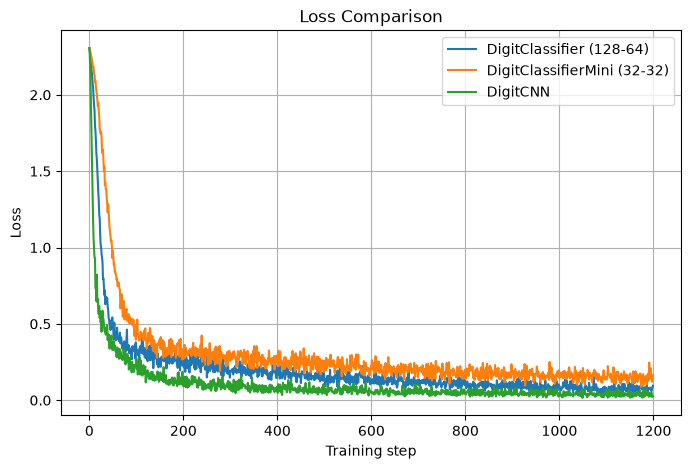

In [7]:
# =====================================
# Loss Curve Comparison
# =====================================
plt.figure(figsize=(8,5))
plt.plot(losses2, label="DigitClassifier (128-64)")
plt.plot(losses1, label="DigitClassifierMini (32-32)")
plt.plot(losses3, label="DigitCNN")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()